# 📑 SECTION 1 : STRATEGY CONCEPT & HYPOTHESIS

**Objectif** : Définir l'idée de trading, son rationnel économique et bâtir un plan d'action.

### 💡 Points Importants :
*   **Rationnel** : Pourquoi cet avantage devrait-il exister ?
*   **Hypothèse** : Définition claire du signal X et de la cible Y.
*   **Audit** : Recenser les modules existants utilisables.

# 📥 SECTION 2 : DATA PIPELINE & QUALITY

**Objectif** : Acquisition de données standardisées, propres et sans biais (OHLCV).

### 💡 Points Importants :
*   **Sanity Check** : Pas de NaN, pas de doublons, fuseau horaire UTC unique.
*   **Biais** : Éviter le lookahead bias (données futures) et le survivorship bias.

In [1]:
# %% [markdown]
# # 🏗️ DATA PIPELINE V2.3 (Joblib Turbo Cache)
# Optimisation : Utilise Joblib+LZ4 pour un chargement/sauvegarde ultra-rapide du dictionnaire.
# Structure : Data Lake (Stockage) -> Working Set (Backtest).

# %%
import pandas as pd
import numpy as np
import vectorbt as vbt
import os
import joblib  # 👈 Remplaçant de Pickle pour la vitesse
import pytz
from data.loaders import load_data

# ==========================================
# 1. CONFIGURATION DU STOCKAGE (DATA LAKE)
# ==========================================
CACHE_ASSETS     = ["EURUSD", "GBPUSD", "XAUUSD", "NASDAQ", "SP500", "USDJPY", "USDCAD", "AUDUSD"]
CACHE_TIMEFRAMES = ["1min","3min","5min", "15min", "30min", "1h", "4h", "1D"] 

USER_TIMEZONE = "Europe/Paris"
START_DATE    = "2020-01-01"
END_DATE      = "2025-12-31"

# Extension .joblib pour la performance
CACHE_FILE    = "aligned_matrix_full_cache.joblib" 
FORCE_RELOAD  = False

# ==========================================
# 2. CONFIGURATION DE TRAVAIL (BACKTEST)
# ==========================================
WORK_ASSETS     = ["EURUSD", "GBPUSD", "XAUUSD", "NASDAQ", "SP500", "USDJPY", "USDCAD", "AUDUSD"] 
WORK_TIMEFRAMES = ["1min","3min","5min", "15min", "30min", "1h", "4h", "1D"]                            
WORK_START_DATE = "2020-01-01"
WORK_END_DATE   = "2023-12-31"


In [2]:

# ==========================================
# 🛠️ MOTEUR INTELLIGENT
# ==========================================

def get_utc_bounds(tz_name, start_str, end_str):
    tz = pytz.timezone(tz_name)
    start_local = pd.Timestamp(start_str).tz_localize(tz)
    end_local   = pd.Timestamp(end_str).tz_localize(tz) + pd.Timedelta(days=1) - pd.Timedelta(nanoseconds=1)
    return start_local.tz_convert("UTC"), end_local.tz_convert("UTC")

def fetch_and_filter_data():
    full_data = None
    need_build = True
    
    # --- A. GESTION DU CACHE (JOBLIB) ---
    if os.path.exists(CACHE_FILE) and not FORCE_RELOAD:
        print(f"⚡ Cache Joblib détecté : {CACHE_FILE}")
        try:
            # Load optimisé pour NumPy/Pandas
            loaded_data = joblib.load(CACHE_FILE)
            
            cached_tfs = list(loaded_data.keys())
            if all(tf in cached_tfs for tf in CACHE_TIMEFRAMES):
                print(f"✔️ Cache valide (Lake : {START_DATE} -> {END_DATE}).")
                full_data = loaded_data
                need_build = False
            else:
                print(f"⚠️ Cache incomplet. Régénération...")
        except Exception as e:
            print(f"⚠️ Cache illisible ({e}). Régénération...")

    # --- B. CONSTRUCTION ---
    if need_build:
        print("🔄 Construction du Data Lake (ETL)...")
        lake_start_utc, lake_end_utc = get_utc_bounds(USER_TIMEZONE, START_DATE, END_DATE)
        
        temp_storage = {tf: {} for tf in CACHE_TIMEFRAMES}
        base_tf_load = "1m"

        for asset in CACHE_ASSETS:
            print(f"   📂 Traitement : {asset}...")
            try:
                df_raw = load_data(asset, base_tf_load, mode="ohlcv")
                # Normalisation TZ
                if df_raw.index.tz is None: df_raw.index = df_raw.index.tz_localize("UTC")
                else: df_raw.index = df_raw.index.tz_convert("UTC")

                for tf in CACHE_TIMEFRAMES:
                    resampled = pd.DataFrame()
                    resampled["open"]   = df_raw["open"].resample(tf).first()
                    resampled["high"]   = df_raw["high"].resample(tf).max()
                    resampled["low"]    = df_raw["low"].resample(tf).min()
                    resampled["close"]  = df_raw["close"].resample(tf).last()
                    resampled["volume"] = df_raw["volume"].resample(tf).sum()
                    resampled = resampled.dropna()

                    mask = (resampled.index >= lake_start_utc) & (resampled.index <= lake_end_utc)
                    df_clean = resampled.loc[mask].copy()
                    df_clean = df_clean[df_clean["volume"] > 0] # Noise filter

                    if not df_clean.empty:
                        temp_storage[tf][asset] = df_clean
            except Exception as e:
                print(f"   ❌ Erreur data {asset}: {e}")

        full_data = {}
        print("🏛️  Alignement Matriciel Global...")
        
        for tf in CACHE_TIMEFRAMES:
            assets_dict = temp_storage[tf]
            if not assets_dict: continue
            valid_assets = list(assets_dict.keys())

            try:
                v_close = pd.concat([assets_dict[a]['close'].rename(a) for a in valid_assets], axis=1)
                v_open  = pd.concat([assets_dict[a]['open'].rename(a)  for a in valid_assets], axis=1)
                v_high  = pd.concat([assets_dict[a]['high'].rename(a)  for a in valid_assets], axis=1)
                v_low   = pd.concat([assets_dict[a]['low'].rename(a)   for a in valid_assets], axis=1)
                v_vol   = pd.concat([assets_dict[a]['volume'].rename(a) for a in valid_assets], axis=1)
                
                is_weekday = v_close.index.dayofweek < 5
                is_active = (v_vol.fillna(0) > 0).any(axis=1)
                valid_rows = is_weekday & is_active
                
                v_close = v_close.loc[valid_rows].ffill(limit=5).bfill(limit=5).dropna()
                idx = v_close.index
                
                full_data[tf] = {
                    "close": v_close,
                    "open": v_open.loc[idx].ffill(limit=5).bfill(limit=5),
                    "high": v_high.loc[idx].ffill(limit=5).bfill(limit=5),
                    "low": v_low.loc[idx].ffill(limit=5).bfill(limit=5),
                    "assets": valid_assets
                }
            except ValueError:
                continue

        print(f"💾 Écriture du Cache Joblib : {CACHE_FILE}")
        # compress=3 offre un bon équilibre vitesse/taille
        joblib.dump(full_data, CACHE_FILE, compress=3)

    # --- C. FILTRAGE DE TRAVAIL ---
    print(f"🔍 Préparation Working Set : {WORK_START_DATE} -> {WORK_END_DATE}")
    work_start_utc, work_end_utc = get_utc_bounds(USER_TIMEZONE, WORK_START_DATE, WORK_END_DATE)
    
    final_aligned_data = {}
    
    for tf in WORK_TIMEFRAMES:
        if tf not in full_data:
            print(f"⚠️ Ignoré : TF {tf} absent.")
            continue
            
        data_tf = full_data[tf]
        # 1. Assets
        keep_assets = [a for a in WORK_ASSETS if a in data_tf["assets"]]
        if not keep_assets: continue
            
        # 2. Dates
        idx = data_tf["close"].index
        mask_date = (idx >= work_start_utc) & (idx <= work_end_utc)
        
        if not mask_date.any():
            print(f"⚠️ Aucune donnée pour {tf} sur la période.")
            continue
            
        final_aligned_data[tf] = {
            "close": data_tf["close"].loc[mask_date, keep_assets],
            "open":  data_tf["open"].loc[mask_date, keep_assets],
            "high":  data_tf["high"].loc[mask_date, keep_assets],
            "low":   data_tf["low"].loc[mask_date, keep_assets],
            "assets": keep_assets
        }
        
    print(f"🚀 Données prêtes : {len(final_aligned_data)} TFs, Période {WORK_START_DATE} à {WORK_END_DATE}.")
    return final_aligned_data

# 🔥 EXECUTION
aligned_data = fetch_and_filter_data()

TF_TO_FREQ = {
    "1min": "1min", "3min": "3min", "5min": "5min", "15min": "15min", "30min": "30min",
    "1h": "1h", "4h": "4h", "1D": "1D", "1W": "1W"
}

⚡ Cache Joblib détecté : aligned_matrix_full_cache.joblib
✔️ Cache valide (Lake : 2020-01-01 -> 2025-12-31).
🔍 Préparation Working Set : 2020-01-01 -> 2023-12-31
🚀 Données prêtes : 8 TFs, Période 2020-01-01 à 2023-12-31.


🔎 TF: in] | Assets: 8 | Rows: 1311179
📅 Période : 2020-01-01 22:55:00+00:00 -> 2023-12-29 21:18:00+00:00
⚠️ Total NaNs : 0 (Doit être proche de 0)


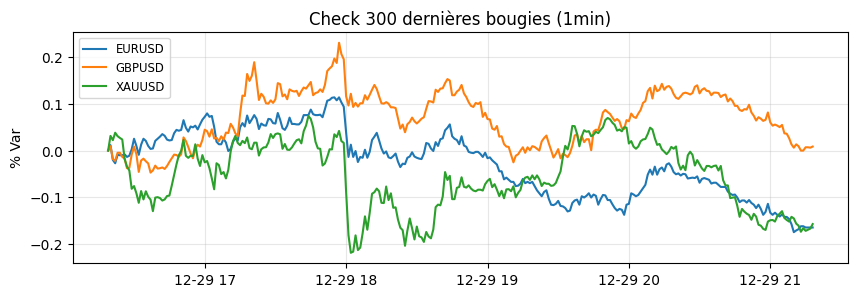

In [3]:
# %% [markdown]
# # ⚡ FAST SANITY CHECK
# Vérification ultra-rapide (Texte + Graphique léger sur les 300 dernières bougies).

# %%
import matplotlib.pyplot as plt

if not aligned_data:
    print("❌ ALERTE : Données vides.")
else:
    # Sélection de la première TF
    tf_check = list(aligned_data.keys())[0]
    df_c = aligned_data[tf_check]["close"]
    
    # 1. Infos Textuelles (Instant)
    n_nans = df_c.isna().sum().sum()
    print(f"🔎 TF: [{tf_check}] | Assets: {len(df_c.columns)} | Rows: {len(df_c)}")
    print(f"📅 Période : {df_c.index[0]} -> {df_c.index[-1]}")
    print(f"⚠️ Total NaNs : {n_nans} (Doit être proche de 0)")
    
    # 2. Graphique "Lite" (Max 3 actifs, Dernières 300 bougies)
    # On ne charge pas tout l'historique dans la mémoire graphique
    subset = df_c.iloc[-300:, :3].copy() 
    
    # Normalisation base 0 pour comparer
    norm = (subset / subset.iloc[0] - 1) * 100
    
    plt.figure(figsize=(10, 3)) # Taille réduite
    for col in norm.columns:
        plt.plot(norm.index, norm[col], label=col, linewidth=1.5)
        
    plt.title(f"Check 300 dernières bougies ({tf_check})")
    plt.ylabel("% Var")
    plt.legend(loc="upper left", fontsize='small')
    plt.grid(True, alpha=0.3)
    plt.show()

# ⚙️ SECTION 3 : FEATURE ENGINEERING (SIGNALS)

**Objectif** : Transformation des données brutes en indicateurs techniques et signaux vectorisés.

### 💡 Points Importants :
*   **Signal X** : Doit être calculé sans aucune donnée future.
*   **Target Y** : Log-returns futurs sur un horizon 'h' défini.
*   **Visual Debug** : Vérifier graphiquement que le code 'voit' ce que vous voyez.

### 🕒 DEBUG BIAIS MTF
Ce graphique permet de voir précisément comment les successions de bougies en **H1, H4 et D1** déterminent le directionnel (Market Bias).
Il aide à valider visuellement que le filtrage MTF se comporte comme prévu.

In [5]:
# 🔍 MODULE 2 : SYNC MTF BREAKDOWN
from viz.core import run_mtf_candlestick_visualizer
run_mtf_candlestick_visualizer(aligned_data, asset="XAUUSD", window=500)

Loading BokehJS ...

### 🕒 DEBUG ENGULFING + FILTRE
Ce graphique permet de voir précisément comment les successions de bougies en **H1, H4 et D1** déterminent le directionnel (Market Bias).
Il aide à valider visuellement que le filtrage MTF se comporte comme prévu.

In [4]:
from viz.core import run_synchronized_debug_bokeh

print("🚀 Lancement du Cockpit de Debugging Visuel...")
TARGET_ASSET  = "XAUUSD"   # Actif à inspecter
BASE_TF       = "15min"    # Timeframe de base
N_BARS        = 300        # Nombre de bougies
EXPIRY_DAYS   = 3          # Expiration Liquidité

if 'aligned_data' in locals():
    run_synchronized_debug_bokeh(aligned_data, TARGET_ASSET, BASE_TF, N_BARS, EXPIRY_DAYS)
else:
    print("❌ Erreur : aligned_data n'est pas chargé. Exécutez la Section 2 d'abord.")

🚀 Lancement du Cockpit de Debugging Visuel...


Loading BokehJS ...

# 🛡️ SECTION 4 : STATISTICAL ALPHA PRE-VALIDATION

**Objectif** : Prouver statistiquement la présence d'un edge avant tout backtest (Le Gatekeeper).

### 💡 Points Importants :
*   **Spearman & MI** : Le signal doit avoir un pouvoir prédictif significatif.
*   **EBTA** : Le profit ne doit pas provenir d'un simple biais de position journalier.
*   **GO / NO GO** : Seul un succès ici autorise le passage aux sections suivantes.

In [ ]:
from pipeline.runner import run_section4_all_assets
from strategies.sweep_lq import SweepLQStrategy

df_summary = run_section4_all_assets(
    aligned_data,
    strategy = SweepLQStrategy(),
    tf       = "15min",
    params   = {"horizon_h": 8, "expiry_days": 3, "tf_minutes": 15},
)

Section 4  |  <Strategy: FausseCassure_MTF_LiquiditySweep>  |  15min  H=8
  ✅ GO (2)    : EURUSD, NASDAQ
  ❌ NO GO (6) : GBPUSD, SP500, USDJPY, USDCAD, XAUUSD, AUDUSD
  → Reports/Section4_Report_15min.html


# 🧠 SECTION 5 : STRATEGY MODELING (LOGIC & RULES)

**Objectif** : Transformer l'alpha validé en règles d'exécution précises (Entrées/Sorties).

### 💡 Points Importants :
*   **Sizing** : Gestion du risque par trade (ex: Loi de Kelly Fractionnaire).
*   **Exits** : Stop Loss, Take Profit, Expiration temporelle ou signal inverse.

# 📈 SECTION 6 : IN-SAMPLE BACKTEST

**Objectif** : Mesurer la performance brute sur les données d'entraînement.

### 💡 Points Importants :
*   **Metrics** : Sharpe > 0.5, Profit Factor > 1.2, Win Rate réaliste.
*   **Coûts** : Intégration du spread, des commissions et du slippage de base.

In [ ]:
# [SECTION 6 - SHELVED / WORK IN PROGRESS]
pass

# 🧪 SECTION 7 : WALK-FORWARD & OOS VALIDATION

**Objectif** : Détecter le sur-apprentissage (overfitting) via des données jamais vues.

### 💡 Points Importants :
*   **Stabilité** : La performance OOS doit rester proche de la performance In-Sample.
*   **WFA** : Ré-optimisation glissante pour vérifier la robustesse locale.

In [ ]:
# [SECTION 7 - SHELVED / WORK IN PROGRESS]
pass

# 🌪️ SECTION 8 : ROBUSTNESS & STRESS TESTS

**Objectif** : Tester la résistance de la stratégie aux conditions extrêmes.

### 💡 Points Importants :
*   **Monte Carlo** : Simulation de 1000 chemins avec permutation des trades.
*   **Sensibilité** : Vérifier que de petits changements de paramètres ne brisent pas l'algo.

In [ ]:
# [SECTION 8 - SHELVED / WORK IN PROGRESS]
pass

# 🏭 SECTION 9 : REALISTIC SIMULATION (FRIC TION)

**Objectif** : Modéliser l'impact réel de la latence et de la liquidité.

### 💡 Points Importants :
*   **Slippage Avancé** : Simulation de dégradation des prix d'exécution.
*   **MQL5 Prep** : Formatage des signaux pour le passage en production.

In [ ]:
# [SECTION 9 - SHELVED / WORK IN PROGRESS]
pass

# 🚀 SECTION 10 : PRODUCTION & MONITORING

**Objectif** : Déploiement live et surveillance active des dérives.

### 💡 Points Importants :
*   **Watchdog** : Alertes en cas d'anomalie d'exécution.
*   **Regime Monitor** : Arrêt automatique si le régime de marché devient hostile.

In [ ]:
# [SECTION 10 - SHELVED / WORK IN PROGRESS]
pass